=== DONNÉES AVEC PRÉDICTIONS ===
   Age  Revenu  Achat  Probabilité_Achat
0   22    2500      0                0.0
1   25    3000      0                0.0
2   28    3500      0                0.0
3   30    4000      1                1.0
4   32    4200      1                1.0
5   35    4500      1                1.0
6   38    5000      1                1.0
7   40    5200      1                1.0
8   45    5500      1                1.0
9   50    6000      1                1.0

=== MATRICE DE CONFUSION ===
[[3 0]
 [0 7]]

=== RAPPORT DE CLASSIFICATION ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         7

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10


=== MÉTRIQUES ROC ===
AUC (Air Under Curve): 1.000

Points de la courbe ROC :
   Seuil  FPR (False Positive 

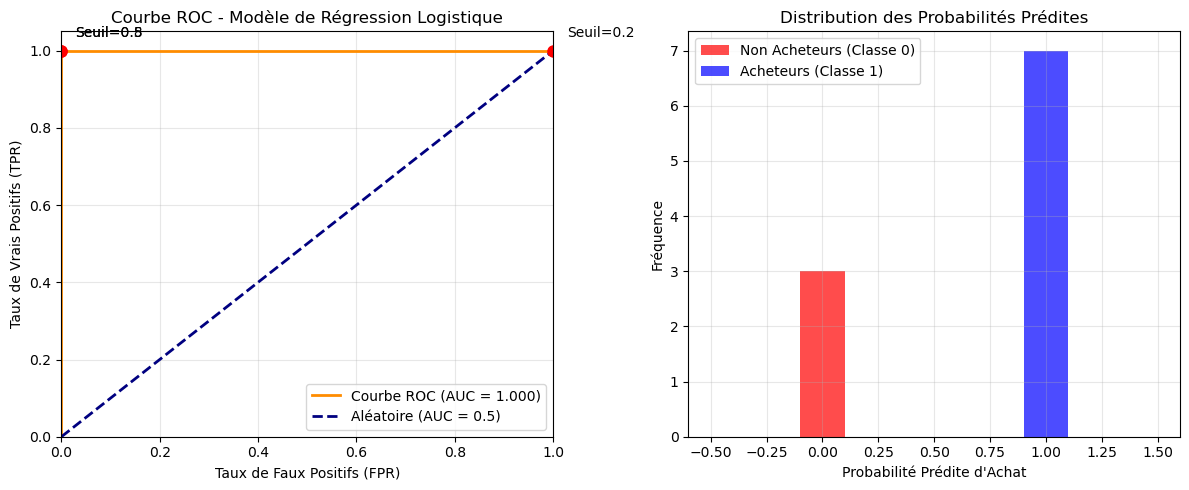

=== ANALYSE PAR SEUIL ===

Seuil = 0.3:
  Vrais Positifs (TP): 7
  Faux Positifs (FP): 0
  Vrais Négatifs (TN): 3
  Faux Négatifs (FN): 0
  Exactitude: 1.000
  TPR (Sensibilité): 1.000
  FPR: 0.000

Seuil = 0.5:
  Vrais Positifs (TP): 7
  Faux Positifs (FP): 0
  Vrais Négatifs (TN): 3
  Faux Négatifs (FN): 0
  Exactitude: 1.000
  TPR (Sensibilité): 1.000
  FPR: 0.000

Seuil = 0.7:
  Vrais Positifs (TP): 7
  Faux Positifs (FP): 0
  Vrais Négatifs (TN): 3
  Faux Négatifs (FN): 0
  Exactitude: 1.000
  TPR (Sensibilité): 1.000
  FPR: 0.000

=== INTERPRÉTATION ===
• AUC = 1.0 : Modèle parfait
• 0.9 ≤ AUC < 1.0 : Excellent
• 0.8 ≤ AUC < 0.9 : Bon
• 0.7 ≤ AUC < 0.8 : Acceptable
• 0.5 ≤ AUC < 0.7 : Médiocre
• AUC = 0.5 : Aléatoire

Notre modèle a un AUC de 1.000 → Modèle parfait !


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, classification_report

# Jeu de données
data = pd.DataFrame({
    'Age': [22,25,28,30,32,35,38,40,45,50],
    'Revenu': [2500,3000,3500,4000,4200,4500,5000,5200,5500,6000],
    'Achat': [0,0,0,1,1,1,1,1,1,1]
})

X = data[['Age', 'Revenu']]
y = data['Achat']

# Modèle
model = LogisticRegression()
model.fit(X, y)

# Prédictions
proba = model.predict_proba(X)[:,1]
data['Probabilité_Achat'] = proba.round(3)

print("=== DONNÉES AVEC PRÉDICTIONS ===")
print(data)
print()

# Prédictions de classe
y_pred = model.predict(X)

# Matrice de confusion
print("=== MATRICE DE CONFUSION ===")
cm = confusion_matrix(y, y_pred)
print(cm)
print()

# Rapport de classification
print("=== RAPPORT DE CLASSIFICATION ===")
print(classification_report(y, y_pred))
print()

# Calcul des métriques ROC
auc_score = roc_auc_score(y, proba)
fpr, tpr, thresholds = roc_curve(y, proba)

print(f"=== MÉTRIQUES ROC ===")
print(f"AUC (Air Under Curve): {auc_score:.3f}")
print()

# Affichage des points de la courbe ROC
roc_data = pd.DataFrame({
    'Seuil': thresholds,
    'FPR (False Positive Rate)': fpr,
    'TPR (True Positive Rate)': tpr
})
print("Points de la courbe ROC :")
print(roc_data.round(3))
print()

# Courbe ROC
plt.figure(figsize=(12, 5))

# Sous-graphique 1 : Courbe ROC
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aléatoire (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC - Modèle de Régression Logistique')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Ajouter quelques points importants sur la courbe
seuils_importants = [0.2, 0.5, 0.8]
for seuil in seuils_importants:
    idx = np.argmin(np.abs(thresholds - seuil))
    plt.plot(fpr[idx], tpr[idx], 'ro', markersize=8)
    plt.annotate(f'Seuil={seuil:.1f}', (fpr[idx], tpr[idx]), 
                xytext=(10, 10), textcoords='offset points')

# Sous-graphique 2 : Distribution des probabilités
plt.subplot(1, 2, 2)
# Séparation des classes
classe_0 = data[data['Achat'] == 0]['Probabilité_Achat']
classe_1 = data[data['Achat'] == 1]['Probabilité_Achat']

plt.hist(classe_0, alpha=0.7, label='Non Acheteurs (Classe 0)', color='red', bins=5)
plt.hist(classe_1, alpha=0.7, label='Acheteurs (Classe 1)', color='blue', bins=5)
plt.xlabel("Probabilité Prédite d'Achat")
plt.ylabel('Fréquence')
plt.title('Distribution des Probabilités Prédites')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analyse détaillée pour différents seuils
print("=== ANALYSE PAR SEUIL ===")
seuils_analyse = [0.3, 0.5, 0.7]

for seuil in seuils_analyse:
    predictions_seuil = (proba >= seuil).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, predictions_seuil).ravel()
    
    print(f"\nSeuil = {seuil}:")
    print(f"  Vrais Positifs (TP): {tp}")
    print(f"  Faux Positifs (FP): {fp}")
    print(f"  Vrais Négatifs (TN): {tn}")
    print(f"  Faux Négatifs (FN): {fn}")
    print(f"  Exactitude: {(tp + tn) / len(y):.3f}")
    print(f"  TPR (Sensibilité): {tp / (tp + fn):.3f}")
    print(f"  FPR: {fp / (fp + tn):.3f}")

# Interprétation des résultats
print("\n=== INTERPRÉTATION ===")
print("• AUC = 1.0 : Modèle parfait")
print("• 0.9 ≤ AUC < 1.0 : Excellent")
print("• 0.8 ≤ AUC < 0.9 : Bon")
print("• 0.7 ≤ AUC < 0.8 : Acceptable")
print("• 0.5 ≤ AUC < 0.7 : Médiocre")
print("• AUC = 0.5 : Aléatoire")

print(f"\nNotre modèle a un AUC de {auc_score:.3f} → ", end="")
if auc_score == 1.0:
    print("Modèle parfait !")
elif auc_score >= 0.9:
    print("Performance excellente !")
elif auc_score >= 0.8:
    print("Bon modèle.")
elif auc_score >= 0.7:
    print("Performance acceptabl")
    print("Performance acceptable.")
else:
    print("Performance médiocre.")